<a href="https://colab.research.google.com/github/Bauk006/uas-bigdata-reddit-data-sience-post-kelompok2/blob/main/Kode_Implementasi_Algoritma_Project_UAS_Kelompok_2_Big_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import LatentDirichletAllocation

!pip install pyLDAvis gensim

import gensim
from gensim.models import CoherenceModel
from gensim.corpora.dictionary import Dictionary
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

## **Load Data**

In [ ]:
import pandas as pd

# Memuat dataset
print("Memuat dataset hasil ETL Pentaho...")
df = pd.read_csv("feature_reddit_data.csv", engine='python', on_bad_lines='warn')

# Cek kolom dataset
print("Kolom yang tersedia dalam file:", df.columns.tolist())

# Membuat clean_text dari title
if 'title' in df.columns:
    df['clean_text'] = df['title'].astype(str).fillna('')
    print("Berhasil menggunakan 'title' sebagai sumber clean_text.")
else:
    print("ERROR: Kolom 'title' tidak ditemukan di file CSV!")

# Hapus data kosong
df = df.dropna(subset=['clean_text'])
df = df[df['clean_text'].str.strip() != '']
df = df.reset_index(drop=True)

print(f"Dataset siap. Jumlah baris: {len(df)}")

Memuat dataset hasil ETL Pentaho...
Kolom yang tersedia dalam file: ['engagement', 'engagement_category', 'post_length', 'subreddit', 'title', 'author', 'score', 'num_comments', 'post', 'created_at']
Berhasil menggunakan 'title' sebagai sumber clean_text.
Dataset siap. Jumlah baris: 261218


In [ ]:
# 1. Cek apakah kolom benar-benar ada
if 'engagement_category' in df.columns:
    print("Kolom ditemukan.")
    # 2. Cek isi unik untuk melihat format tulisan (Case sensitive)
    print("Isi unik:", df['engagement_category'].unique())
    # 3. Cek distribusi data
    print("Jumlah data per kategori:\n", df['engagement_category'].value_counts())
else:
    print("ERROR: Kolom 'engagement_category' tidak ada di dataframe!")

Kolom ditemukan.
Isi unik: ['Low' 'Medium' 'High']
Jumlah data per kategori:
 engagement_category
Low       258937
Medium      2178
High         103
Name: count, dtype: int64


## **Topic Modeling (LDA) pada Kelas High Engagement**

In [ ]:
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
import warnings
warnings.filterwarnings("ignore")

if 'engagement_category' in df.columns:
    print("Menggunakan kolom engagement_category hasil Pentaho.")
else:
    print("Peringatan: Kolom tidak ditemukan di Pentaho, melakukan kalkulasi ulang (Cek threshold!).")
    df['engagement'] = df['score'] + df['num_comments']
    df['engagement_category'] = df['engagement'].apply(lambda x: 'High' if x >= 200 else ('Medium' if x >= 50 else 'Low'))

# Filter data
df_high = df[df['engagement_category'] == 'High'].copy()
print(f"Jumlah data High Engagement: {len(df_high)}\n")

# Validasi isi
if df_high.empty:
    print("ERROR: Tidak ada data dengan label 'High'. Cek kembali threshold kamu!")
else:
    # Corpus LDA
    texts = [str(text).split() for text in df_high['clean_text']]
    dictionary = Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Model LDA
    lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, random_state=42, passes=15)

    # Output
    print("=== KATA KUNCI PER TOPIK ===")
    for idx, topic in lda_model.print_topics(-1): print(f"Topik {idx+1}: {topic}")

    # Evaluasi
    print(f"\nPerplexity: {lda_model.log_perplexity(corpus):.4f}")
    coherence_model = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
    print(f"Coherence Score: {coherence_model.get_coherence():.4f}")

Menggunakan kolom engagement_category hasil Pentaho.
Jumlah data High Engagement: 103

=== KATA KUNCI PER TOPIK ===
Topik 1: 0.017*"on" + 0.014*"[N]" + 0.014*"with" + 0.014*"Siraj" + 0.010*"AI" + 0.010*"Raval" + 0.007*"[D]" + 0.007*"[News]" + 0.007*"his" + 0.007*"[P]"
Topik 2: 0.022*"a" + 0.022*"and" + 0.017*"I" + 0.017*"the" + 0.017*"[D]" + 0.015*"of" + 0.015*"to" + 0.010*"Google" + 0.010*"as" + 0.010*"with"
Topik 3: 0.023*"and" + 0.020*"[D]" + 0.015*"is" + 0.015*"for" + 0.012*"your" + 0.009*"How" + 0.009*"of" + 0.009*"a" + 0.009*"as" + 0.009*"AI"
Topik 4: 0.031*"[D]" + 0.015*"of" + 0.015*"Machine" + 0.015*"Learning" + 0.012*"from" + 0.009*"data" + 0.009*"is" + 0.009*"its" + 0.009*"are" + 0.009*"IEEE"
Topik 5: 0.023*"to" + 0.021*"[D]" + 0.017*"a" + 0.016*"the" + 0.013*"is" + 0.013*"and" + 0.013*"[N]" + 0.011*"has" + 0.011*"-" + 0.011*"on"

Perplexity: -6.8295
Coherence Score: 0.4207


## **Intertopic Distance Map**

In [ ]:
# Visualisasi hasil LDA
pyLDAvis.enable_notebook()

vis = gensimvis.prepare(lda_model, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.059608  0.002826       1        1  24.536132
4      0.109349 -0.016814       2        1  22.432120
3     -0.072810 -0.082515       3        1  18.974380
2     -0.050312 -0.019073       4        1  18.849596
0     -0.045834  0.115577       5        1  15.207772, topic_info=       Term      Freq     Total Category  logprob  loglift
124    with  5.000000  5.000000  Default  30.0000  30.0000
67       on  8.000000  8.000000  Default  29.0000  29.0000
374     [N]  7.000000  7.000000  Default  28.0000  28.0000
39        I  7.000000  7.000000  Default  27.0000  27.0000
199   Siraj  5.000000  5.000000  Default  26.0000  26.0000
..      ...       ...       ...      ...      ...      ...
34     full  0.676924  1.800746   Topic5  -5.5570   0.9050
591    2020  0.676867  1.799951   Topic5  -5.5570   0.9053
434  people  0.676838  3.081213   Topic5  -5.5571   0.3677
126  Anyone  0.676817  1.832699   Topic5  -5.5571   0.8872
138      an  0.676790  3.697354   Topic5  -5.5572   0.1854

[299 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
194       1  0.511433  'The
57        2  0.784104     -
57        4  0.261368     -
591       3  0.555571  2020
591       5  0.555571  2020
...     ...       ...   ...
101       1  0.315197  your
101       2  0.157598  your
101       3  0.157598  your
101       4  0.472795  your
635       2  0.788123    “A

[365 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 5, 4, 3, 1])

## **Word Cloud per Topik**

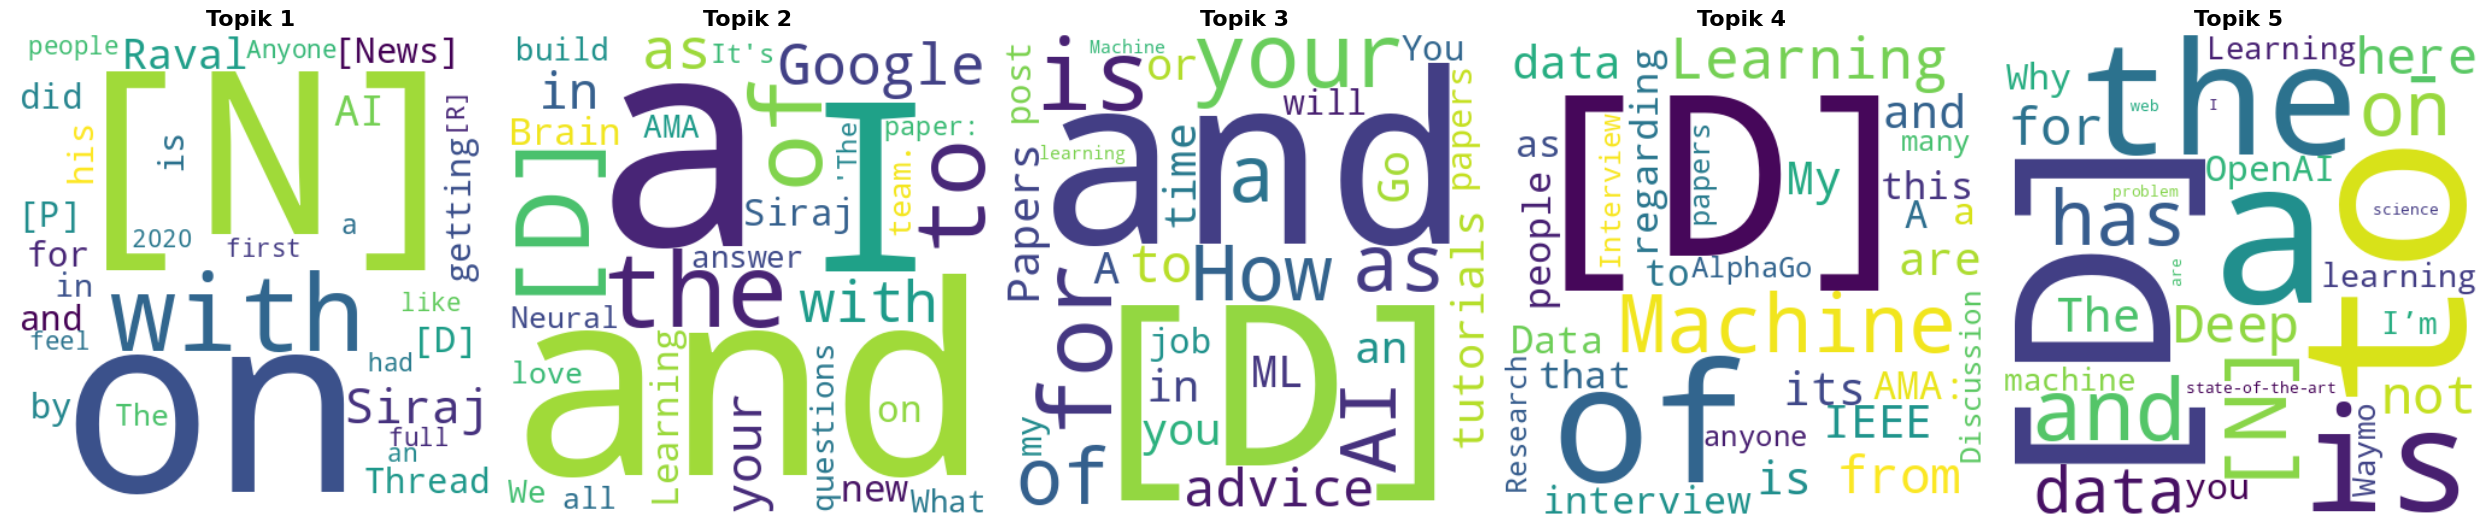

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Membuat visualisasi Word Cloud tiap topik
fig, axes = plt.subplots(1, 5, figsize=(25, 6), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    fig.add_subplot(ax)

    # Ambil kata kunci topik
    topic_words = dict(lda_model.show_topic(i, topn=30))

    # Generate Word Cloud
    cloud = WordCloud(
        background_color='white',
        width=400,
        height=400,
        colormap='viridis'
    ).generate_from_frequencies(topic_words)

    plt.gca().imshow(cloud, interpolation='bilinear')
    plt.gca().set_title(f'Topik {i+1}', fontdict=dict(size=16, weight='bold'))
    plt.gca().axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!pip install imbalanced-learn

## **Analisis Prediktif (Random Forest)**

In [ ]:
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# Mapping Kategori ke Biner
def make_binary(cat):
    return 'Viral' if cat in ['High', 'Medium'] else 'Low'

df['label_binary'] = df['engagement_category'].apply(make_binary)

# Fitur Engineering
if 'post_length' not in df.columns:
    df['post_length'] = df['title'].astype(str).apply(len)

# TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
X_text = tfidf.fit_transform(df['clean_text'].astype(str))

# Gabungkan Fitur
post_length_array = df['post_length'].values.reshape(-1, 1)
X_final = sp.hstack((X_text, post_length_array))

# Target Biner
y = df['label_binary']

# Split dengan Stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Training
print("Memulai pelatihan Binary Classification (Viral vs Low)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=2)
rf_model.fit(X_train_resampled, y_train_resampled)

# Evaluasi
y_pred = rf_model.predict(X_test)
print("\n=== CLASSIFICATION REPORT (BINARY: VIRAL VS LOW) ===")
print(classification_report(y_test, y_pred))

Memulai pelatihan Binary Classification (Viral vs Low)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  5.3min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 13.7min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    2.4s finished



=== CLASSIFICATION REPORT (BINARY: VIRAL VS LOW) ===
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99     51788
       Viral       0.09      0.10      0.09       456

    accuracy                           0.98     52244
   macro avg       0.54      0.54      0.54     52244
weighted avg       0.98      0.98      0.98     52244

